# Daily Sentiment Aggregation

This notebook aggregates article-level FinBERT sentiment scores into **daily stock-level features**  
that can be merged with OHLCV data for model training.

**Pipeline position:** Runs after `sentiment_pipeline.ipynb`  
**Input:** `sentiment_title` and `sentiment_title_content` tables (one row per article)  
**Output:** `daily_sentiment_title` and `daily_sentiment_title_content` tables (one row per stock per trading day)

### Key design decisions
- **Trading day mapping:** Articles are assigned to the trading day whose market close they precede.  
  Bursa Malaysia closes at 5:00 PM MYT (UTC+8). Articles published between the previous close and the current close belong to the current trading day.  
  Weekend/holiday articles roll forward to the next trading day.
- **Aggregation method:** Confidence-weighted average — articles where FinBERT was more certain contribute more to the daily score.
- **Missing days:** Left as NaN for the modelling team to handle (forward-fill, interpolation, or neutral defaults).
- **Configurations:** Both title-only and title+content are aggregated.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta, time

# ============================================================
# CONSTANTS
# ============================================================
DB_PATH = '../data/database.db'
OUTPUT_DIR = '../data/daily_sentiment_exports'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Bursa Malaysia market close: 5:00 PM MYT (UTC+8)
# Articles published between previous close and current close
# are assigned to the current trading day.
MARKET_CLOSE_HOUR = 17  # 5:00 PM
MYT_OFFSET_HOURS = 8   # UTC+8

TICKERS = {
    '1155.KL': 'Maybank',
    '1023.KL': 'CIMB',
    '1295.KL': 'PublicBank',
    '5211.KL': 'Sunway',
    '5225.KL': 'IHH',
    '5285.KL': 'SDGuthrie',
    '5347.KL': 'Tenaga',
    '5819.KL': 'HongLeongBank',
    '6947.KL': 'CelcomDigi',
    '8869.KL': 'PressMetal'
}

# ============================================================
# LOAD SENTIMENT DATA
# ============================================================
connection = sqlite3.connect(DB_PATH)
df_title = pd.read_sql_query('SELECT * FROM sentiment_title', connection)
df_title_content = pd.read_sql_query('SELECT * FROM sentiment_title_content', connection)
connection.close()

print(f"Title-only articles loaded: {len(df_title)}")
print(f"Title+content articles loaded: {len(df_title_content)}")
print(f"\nColumns: {df_title.columns.tolist()}")
print(f"\nTickers: {df_title['ticker'].unique()}")
print(f"\nDate range (unix): {df_title['pubdateunix'].min()} to {df_title['pubdateunix'].max()}")

Title-only articles loaded: 25989
Title+content articles loaded: 25989

Columns: ['ticker', 'article_id', 'pubdateunix', 'title', 'kicker', 'text_used', 'prob_pos', 'prob_neu', 'prob_neg', 'sentiment_score', 'directional_label', 'confidence', 'strength']

Tickers: <StringArray>
['1155.KL', '1023.KL', '1295.KL', '5211.KL', '5225.KL', '5285.KL', '5347.KL',
 '5819.KL', '6947.KL', '8869.KL']
Length: 10, dtype: str

Date range (unix): 1597359600 to 1773385320


## Step 1: Convert Timestamps and Assign Trading Days

Bursa Malaysia closes at 5:00 PM MYT. An article published at 3:00 PM on Monday  
belongs to Monday's trading day. An article published at 7:00 PM on Monday belongs  
to Tuesday's trading day. Weekend articles roll forward to Monday.

In [2]:
def assign_trading_day(pubdateunix):
    """
    Assigns an article to a calendar date based on Bursa Malaysia's
    5:00 PM MYT market close.
    
    Articles published before 5:00 PM MYT -> that calendar date
    Articles published at/after 5:00 PM MYT -> next calendar date
    
    Weekend/holiday alignment is handled separately using the
    actual trading calendar.
    """
    # Convert unix timestamp to MYT datetime
    utc_dt = datetime.utcfromtimestamp(pubdateunix)
    myt_dt = utc_dt + timedelta(hours=MYT_OFFSET_HOURS)
    
    # If published at or after market close, assign to next calendar date
    if myt_dt.hour >= MARKET_CLOSE_HOUR:
        return (myt_dt + timedelta(days=1)).date()
    else:
        return myt_dt.date()


def align_to_trading_calendar(dates_series, trading_dates):
    """
    Maps calendar dates to the next available trading date.
    Weekend and holiday articles roll forward to the next trading day.
    
    Parameters:
        dates_series: Series of datetime.date values (assigned calendar dates)
        trading_dates: sorted list/array of actual trading dates
    
    Returns:
        Series of aligned trading dates
    """
    trading_dates = sorted(trading_dates)
    
    def find_next_trading_day(d):
        # Binary search for the next trading date >= d
        idx = np.searchsorted(trading_dates, d)
        if idx < len(trading_dates):
            return trading_dates[idx]
        else:
            # Article is after the last trading date in our data
            return None
    
    return dates_series.apply(find_next_trading_day)


# Apply calendar date assignment to both dataframes
for df, name in [(df_title, 'title'), (df_title_content, 'title+content')]:
    df['calendar_date'] = df['pubdateunix'].apply(assign_trading_day)
    df['calendar_date'] = pd.to_datetime(df['calendar_date'])
    print(f"{name} date range: {df['calendar_date'].min().date()} to {df['calendar_date'].max().date()}")

print(f"\nSample calendar date assignment:")
print(df_title[['ticker', 'title', 'pubdateunix', 'calendar_date']].head(5).to_string())

title date range: 2020-08-14 to 2026-03-13
title+content date range: 2020-08-14 to 2026-03-13

Sample calendar date assignment:
    ticker                                                                     title  pubdateunix calendar_date
0  1155.KL            CELEBRATE THE FESTIVE SEASON WITH GREATER REWARDS FROM MAYBANK   1772838000    2026-03-07
1  1155.KL            Celebrate the festive season with greater rewards from Maybank   1772838660    2026-03-07
2  1155.KL  Maybank's net profit rises to RM10.51bil in FY25, declares 33c div/share   1772083380    2026-02-26
3  1155.KL   Maybank, TNB Electron launch EV charging pilot at Maybank Academy Bangi   1771920900    2026-02-24
4  1155.KL                      Maybank appoints Chua as group COO effective April 1   1771887600    2026-02-24


## Step 2: Build Trading Calendar from OHLCV Data

We derive the actual Bursa Malaysia trading calendar from the OHLCV data  
(which your teammates will have collected via yfinance). This is more reliable  
than hardcoding holidays, since yfinance only returns rows for actual trading days.

**If OHLCV data is not yet available**, we fall back to a weekday-only calendar  
and flag that holiday alignment is approximate.

In [3]:
# ============================================================
# ATTEMPT TO LOAD TRADING CALENDAR FROM OHLCV DATA
# ============================================================

# Try loading OHLCV data to extract actual trading dates
# Adjust the table name / file path to match your teammates' data
trading_dates = None
calendar_source = None

try:
    connection = sqlite3.connect(DB_PATH)
    # Try common table names your teammates might use
    for table_name in ['ohlcv', 'stock_data', 'price_data', 'market_data']:
        try:
            df_ohlcv = pd.read_sql_query(f'SELECT DISTINCT Date FROM {table_name}', connection)
            trading_dates = pd.to_datetime(df_ohlcv['Date']).dt.date.sort_values().unique()
            calendar_source = f'database table: {table_name}'
            print(f"Loaded trading calendar from '{table_name}' table")
            break
        except:
            continue
    connection.close()
except:
    pass

# Fallback: generate weekday-only calendar
if trading_dates is None:
    print("WARNING: No OHLCV data found. Using weekday-only calendar as fallback.")
    print("Holiday alignment will be approximate. Re-run after OHLCV data is available.")
    
    min_date = min(df_title['calendar_date'].min(), df_title_content['calendar_date'].min())
    max_date = max(df_title['calendar_date'].max(), df_title_content['calendar_date'].max())
    
    all_dates = pd.date_range(start=min_date, end=max_date, freq='B')  # B = business days
    trading_dates = all_dates.date
    calendar_source = 'weekday-only fallback (holidays not excluded)'

trading_dates_list = sorted(trading_dates)
print(f"\nTrading calendar source: {calendar_source}")
print(f"Trading dates: {len(trading_dates_list)} days")
print(f"Range: {trading_dates_list[0]} to {trading_dates_list[-1]}")

Holiday alignment will be approximate. Re-run after OHLCV data is available.

Trading calendar source: weekday-only fallback (holidays not excluded)
Trading dates: 1456 days
Range: 2020-08-14 to 2026-03-13


In [4]:
# ============================================================
# ALIGN ARTICLES TO TRADING DAYS
# ============================================================

for df, name in [(df_title, 'title'), (df_title_content, 'title+content')]:
    # Convert calendar_date to date objects for alignment
    calendar_dates = df['calendar_date'].dt.date
    
    # Align to next available trading day
    df['trading_date'] = align_to_trading_calendar(calendar_dates, trading_dates_list)
    df['trading_date'] = pd.to_datetime(df['trading_date'])
    
    # Report articles that couldn't be aligned (after last trading date)
    unaligned = df['trading_date'].isna().sum()
    if unaligned > 0:
        print(f"WARNING: {unaligned} {name} articles could not be aligned (after last trading date)")
    
    # Drop unaligned articles
    df.dropna(subset=['trading_date'], inplace=True)

print(f"\nTitle articles after alignment: {len(df_title)}")
print(f"Title+content articles after alignment: {len(df_title_content)}")

# Sanity check: show some weekend articles that were rolled forward
print("\nSample weekend -> trading day alignment:")
sample = df_title[df_title['calendar_date'].dt.dayofweek >= 5].head(5)
if len(sample) > 0:
    print(sample[['ticker', 'calendar_date', 'trading_date', 'title']].to_string())
else:
    print("No weekend articles found (articles published after market close on Friday roll to Monday)")


Title articles after alignment: 25989
Title+content articles after alignment: 25989

Sample weekend -> trading day alignment:
     ticker calendar_date trading_date                                                                                                                   title
0   1155.KL    2026-03-07   2026-03-09                                                          CELEBRATE THE FESTIVE SEASON WITH GREATER REWARDS FROM MAYBANK
1   1155.KL    2026-03-07   2026-03-09                                                          Celebrate the festive season with greater rewards from Maybank
19  1155.KL    2026-01-31   2026-02-02                                                                      Maybank appoints Rohaya Mohammad Yusof as director
35  1155.KL    2025-11-01   2025-11-03  'Oh dear, it's really hot out there, ' but kudos to the players, they are so cool about it at the Maybank Championship
36  1155.KL    2025-11-02   2025-11-03                                    Mayb

## Step 3: Article Density Analysis

Before aggregating, we need to understand how many articles per stock per trading day  
we actually have. Sparse coverage will produce noisy daily signals.

In [5]:
# ============================================================
# ARTICLE DENSITY PER STOCK PER TRADING DAY
# ============================================================

# Using title+content as representative (same articles, different text input)
density = df_title_content.groupby(['ticker', 'trading_date']).size().reset_index(name='article_count')

print("=== Article Density Statistics (per stock per trading day) ===")
print(density.groupby('ticker')['article_count'].describe().round(2).to_string())

# Overall density summary
print(f"\n=== Overall ===")
print(f"Mean articles per stock per day: {density['article_count'].mean():.2f}")
print(f"Median: {density['article_count'].median():.1f}")
print(f"Days with only 1 article: {(density['article_count'] == 1).sum()} ({(density['article_count'] == 1).mean()*100:.1f}%)")

# Coverage: what % of trading days have at least 1 article?
print(f"\n=== Trading Day Coverage ===")
total_trading_days = len(trading_dates_list)
for ticker, name in TICKERS.items():
    ticker_days = density[density['ticker'] == ticker]['trading_date'].nunique()
    coverage = ticker_days / total_trading_days * 100
    print(f"{ticker} ({name}): {ticker_days}/{total_trading_days} trading days covered ({coverage:.1f}%)")

=== Article Density Statistics (per stock per trading day) ===
          count  mean   std  min  25%  50%  75%   max
ticker                                               
1023.KL   992.0  3.50  1.93  1.0  2.0  3.0  5.0  11.0
1155.KL  1046.0  3.81  2.17  1.0  2.0  4.0  5.0  13.0
1295.KL  1177.0  6.22  3.57  1.0  4.0  6.0  8.0  20.0
5211.KL  1041.0  2.81  1.84  1.0  1.0  2.0  4.0  13.0
5225.KL   447.0  1.48  0.78  1.0  1.0  1.0  2.0   6.0
5285.KL   201.0  1.51  0.86  1.0  1.0  1.0  2.0   5.0
5347.KL   966.0  2.83  1.76  1.0  1.0  2.0  4.0  13.0
5819.KL   943.0  3.10  1.66  1.0  2.0  3.0  4.0  11.0
6947.KL   578.0  1.64  0.97  1.0  1.0  1.0  2.0   7.0
8869.KL   484.0  1.48  0.77  1.0  1.0  1.0  2.0   5.0

=== Overall ===
Mean articles per stock per day: 3.30
Median: 3.0
Days with only 1 article: 2232 (28.3%)

=== Trading Day Coverage ===
1155.KL (Maybank): 1046/1456 trading days covered (71.8%)
1023.KL (CIMB): 992/1456 trading days covered (68.1%)
1295.KL (PublicBank): 1177/1456 trading d

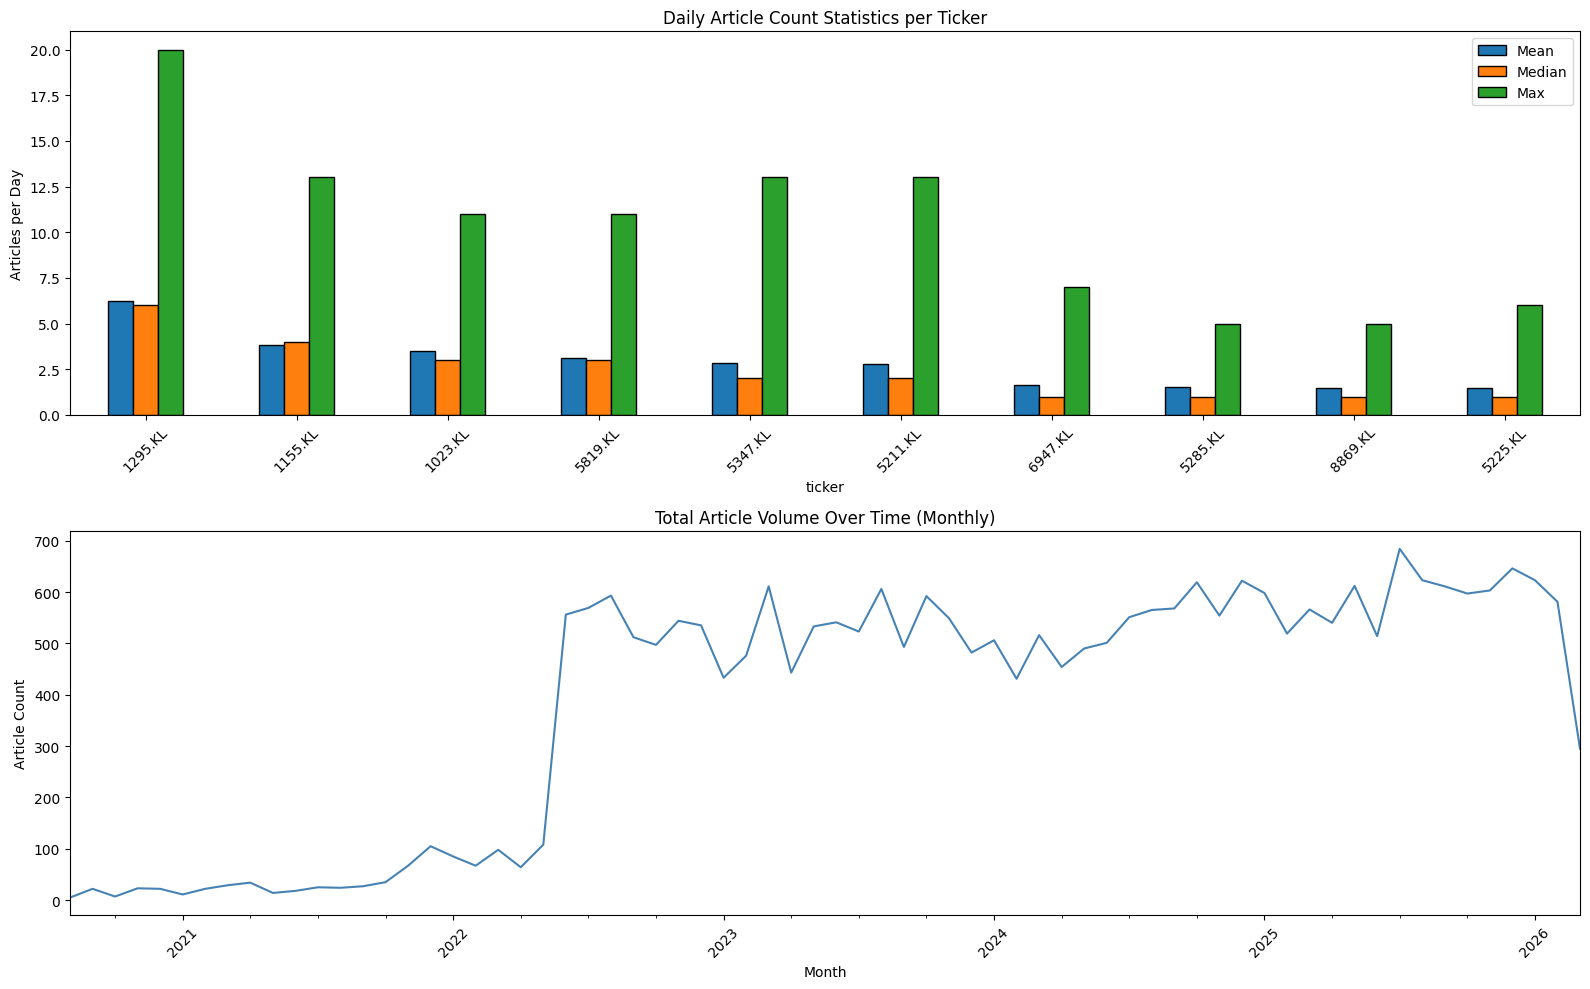

In [6]:
# ============================================================
# VISUALISE ARTICLE DENSITY
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Distribution of daily article counts per ticker
density_pivot = density.pivot_table(index='ticker', values='article_count', 
                                      aggfunc=['mean', 'median', 'max'])
density_pivot.columns = ['Mean', 'Median', 'Max']
density_pivot.sort_values('Mean', ascending=False).plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Daily Article Count Statistics per Ticker')
axes[0].set_ylabel('Articles per Day')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# 2. Article volume over time (all tickers combined, monthly)
monthly_density = df_title_content.copy()
monthly_density['year_month'] = monthly_density['trading_date'].dt.to_period('M')
monthly_counts = monthly_density.groupby('year_month').size()
monthly_counts.plot(kind='line', ax=axes[1], color='steelblue')
axes[1].set_title('Total Article Volume Over Time (Monthly)')
axes[1].set_ylabel('Article Count')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 4: Confidence-Weighted Daily Aggregation

For each stock on each trading day, we compute:
- **Confidence-weighted average** of: sentiment_score, prob_pos, prob_neu, prob_neg, strength
- **One-hot directional proportions**: proportion of articles classified as POSITIVE / NEUTRAL / NEGATIVE
- **Article count** for that day

Weight for each article = its `confidence` value (|prob_pos - prob_neg|).  
Articles where FinBERT was more decisive contribute more to the daily score.

In [7]:
def aggregate_daily_sentiment(df):
    """
    Aggregates article-level sentiment into daily stock-level features
    using confidence-weighted averages.
    
    Parameters:
        df: DataFrame with article-level sentiment (one row per article)
    
    Returns:
        DataFrame with one row per stock per trading day
    """
    
    # Features to aggregate with confidence-weighted average
    weighted_features = ['sentiment_score', 'prob_pos', 'prob_neu', 'prob_neg', 'strength']
    
    results = []
    
    for (ticker, trading_date), group in df.groupby(['ticker', 'trading_date']):
        row = {
            'ticker': ticker,
            'trading_date': trading_date,
            'article_count': len(group)
        }
        
        # Confidence weights
        weights = group['confidence'].values
        weight_sum = weights.sum()
        
        if weight_sum > 0:
            # Confidence-weighted average for numerical features
            for feature in weighted_features:
                row[f'w_{feature}'] = np.average(group[feature].values, weights=weights)
        else:
            # Edge case: all articles have zero confidence (all perfectly neutral)
            # Fall back to simple average
            for feature in weighted_features:
                row[f'w_{feature}'] = group[feature].mean()
        
        # Also store simple (unweighted) average for comparison
        row['avg_sentiment_score'] = group['sentiment_score'].mean()
        row['avg_confidence'] = group['confidence'].mean()
        
        # One-hot directional proportions
        label_counts = group['directional_label'].value_counts()
        total = len(group)
        row['prop_positive'] = label_counts.get('POSITIVE', 0) / total
        row['prop_neutral'] = label_counts.get('NEUTRAL', 0) / total
        row['prop_negative'] = label_counts.get('NEGATIVE', 0) / total
        
        # Dominant sentiment for the day
        row['dominant_sentiment'] = group['directional_label'].mode().iloc[0]
        
        results.append(row)
    
    df_daily = pd.DataFrame(results)
    df_daily['trading_date'] = pd.to_datetime(df_daily['trading_date'])
    df_daily = df_daily.sort_values(['ticker', 'trading_date']).reset_index(drop=True)
    
    return df_daily


# ============================================================
# RUN AGGREGATION FOR BOTH CONFIGURATIONS
# ============================================================
print("Aggregating title-only sentiment...")
df_daily_title = aggregate_daily_sentiment(df_title)
print(f"  Result: {len(df_daily_title)} stock-day records")

print("\nAggregating title+content sentiment...")
df_daily_title_content = aggregate_daily_sentiment(df_title_content)
print(f"  Result: {len(df_daily_title_content)} stock-day records")

# Quick sanity check
print("\n=== Sample daily records (title+content) ===")
print(df_daily_title_content.head(10).to_string())

Aggregating title-only sentiment...
  Result: 7875 stock-day records

Aggregating title+content sentiment...
  Result: 7875 stock-day records

=== Sample daily records (title+content) ===
    ticker trading_date  article_count  w_sentiment_score  w_prob_pos  w_prob_neu  w_prob_neg  w_strength  avg_sentiment_score  avg_confidence  prop_positive  prop_neutral  prop_negative dominant_sentiment
0  1023.KL   2020-08-14              1          -0.056720    0.010528    0.067249    0.922223    0.922223            -0.056720        0.056720            0.0           1.0            0.0            NEUTRAL
1  1023.KL   2020-08-20              1          -0.831294    0.027557    0.858851    0.113592    0.858851            -0.831294        0.831294            0.0           0.0            1.0           NEGATIVE
2  1023.KL   2020-11-11              1          -0.009388    0.043417    0.052805    0.903777    0.903777            -0.009388        0.009388            0.0           1.0            0.0        

## Step 5: Expand to Full Trading Calendar

Create a complete grid of (ticker × trading_date) so that days with no articles  
appear as NaN rows. This makes the data ready to merge with OHLCV data.

In [8]:
def expand_to_full_calendar(df_daily, trading_dates_list, tickers):
    """
    Expands the daily sentiment dataframe to include all trading dates
    for all tickers. Days with no articles will have NaN values
    and article_count = 0.
    """
    # Create full grid: every ticker × every trading date
    full_index = pd.MultiIndex.from_product(
        [list(tickers.keys()), pd.to_datetime(trading_dates_list)],
        names=['ticker', 'trading_date']
    )
    df_full = pd.DataFrame(index=full_index).reset_index()
    
    # Merge with actual daily sentiment data
    df_merged = df_full.merge(
        df_daily,
        on=['ticker', 'trading_date'],
        how='left'
    )
    
    # Set article_count to 0 for days with no articles (instead of NaN)
    df_merged['article_count'] = df_merged['article_count'].fillna(0).astype(int)
    
    df_merged = df_merged.sort_values(['ticker', 'trading_date']).reset_index(drop=True)
    
    return df_merged


# Expand both configurations
print("Expanding to full trading calendar...")
df_daily_title_full = expand_to_full_calendar(df_daily_title, trading_dates_list, TICKERS)
df_daily_title_content_full = expand_to_full_calendar(df_daily_title_content, trading_dates_list, TICKERS)

print(f"Title-only: {len(df_daily_title_full)} total stock-day records")
print(f"Title+content: {len(df_daily_title_content_full)} total stock-day records")

# Report NaN coverage
for df, name in [(df_daily_title_full, 'Title-only'), (df_daily_title_content_full, 'Title+content')]:
    total = len(df)
    missing = df['w_sentiment_score'].isna().sum()
    print(f"\n{name}: {missing}/{total} days with no articles ({missing/total*100:.1f}%)")
    
    # Per ticker breakdown
    print("  Per ticker:")
    for ticker, name_t in TICKERS.items():
        ticker_df = df[df['ticker'] == ticker]
        ticker_missing = ticker_df['w_sentiment_score'].isna().sum()
        ticker_total = len(ticker_df)
        print(f"    {ticker} ({name_t}): {ticker_missing}/{ticker_total} missing ({ticker_missing/ticker_total*100:.1f}%)")

Expanding to full trading calendar...
Title-only: 14560 total stock-day records
Title+content: 14560 total stock-day records

Title-only: 6685/14560 days with no articles (45.9%)
  Per ticker:
    1155.KL (Maybank): 410/1456 missing (28.2%)
    1023.KL (CIMB): 464/1456 missing (31.9%)
    1295.KL (PublicBank): 279/1456 missing (19.2%)
    5211.KL (Sunway): 415/1456 missing (28.5%)
    5225.KL (IHH): 1009/1456 missing (69.3%)
    5285.KL (SDGuthrie): 1255/1456 missing (86.2%)
    5347.KL (Tenaga): 490/1456 missing (33.7%)
    5819.KL (HongLeongBank): 513/1456 missing (35.2%)
    6947.KL (CelcomDigi): 878/1456 missing (60.3%)
    8869.KL (PressMetal): 972/1456 missing (66.8%)

Title+content: 6685/14560 days with no articles (45.9%)
  Per ticker:
    1155.KL (Maybank): 410/1456 missing (28.2%)
    1023.KL (CIMB): 464/1456 missing (31.9%)
    1295.KL (PublicBank): 279/1456 missing (19.2%)
    5211.KL (Sunway): 415/1456 missing (28.5%)
    5225.KL (IHH): 1009/1456 missing (69.3%)
    5285.K

## Step 6: Quality Checks

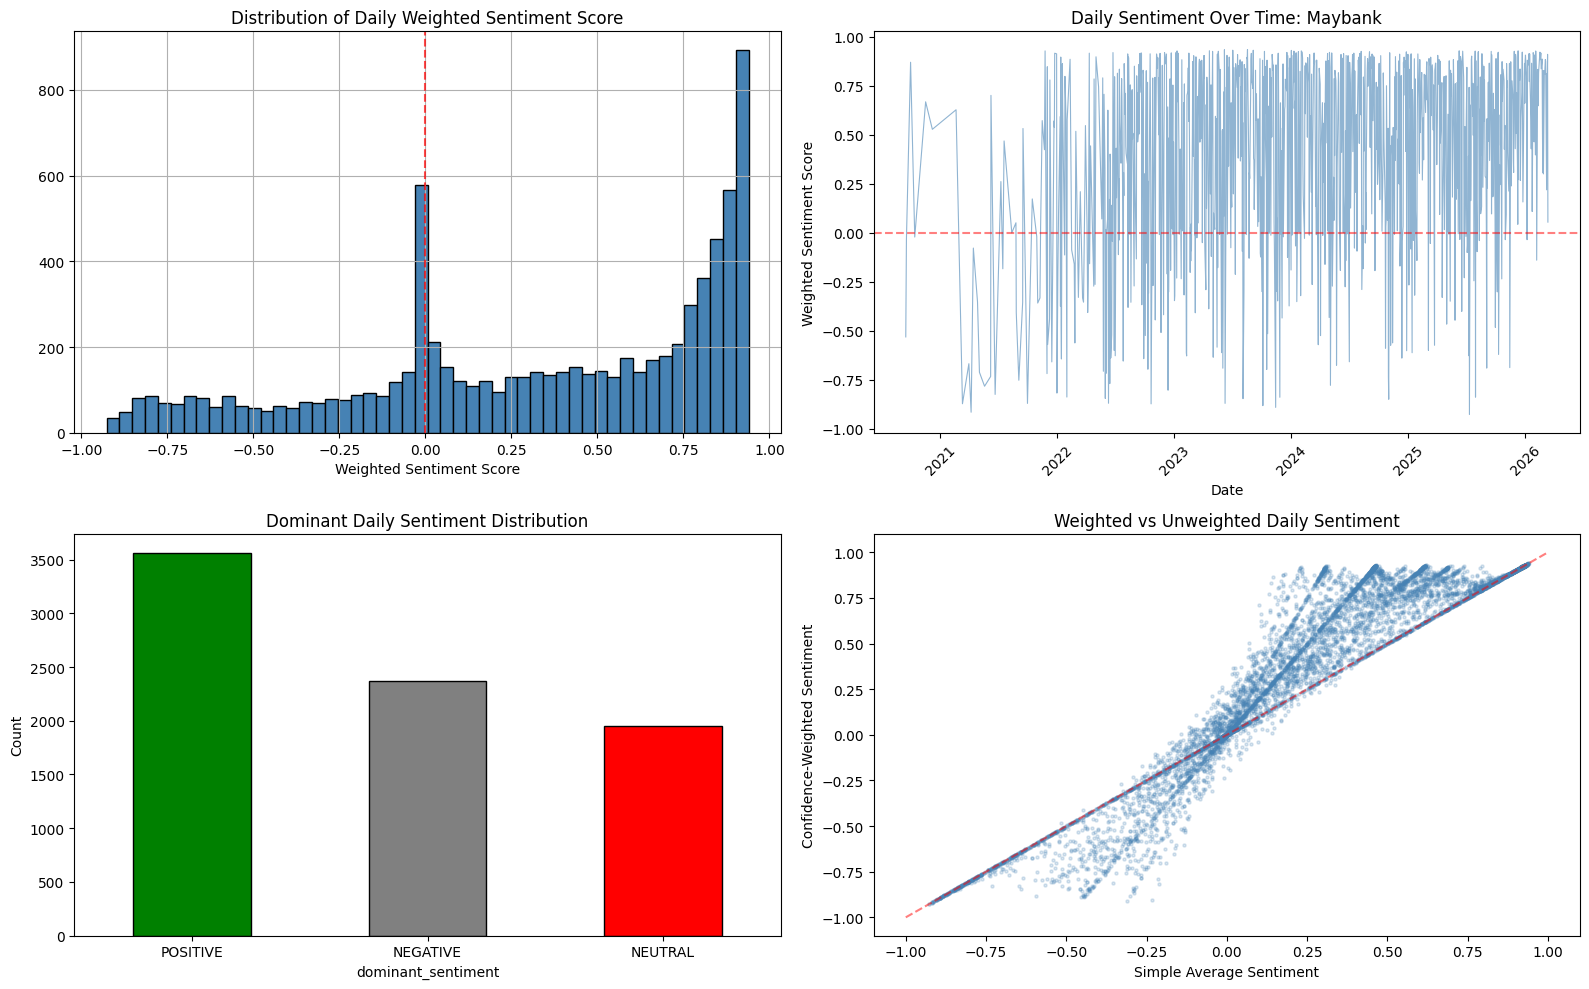

Correlation between weighted and unweighted daily sentiment: 0.9416


In [9]:
# ============================================================
# DISTRIBUTION OF DAILY SENTIMENT SCORES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Use title+content as primary
df_plot = df_daily_title_content_full.dropna(subset=['w_sentiment_score'])

# 1. Distribution of weighted daily sentiment scores
df_plot['w_sentiment_score'].hist(bins=50, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Daily Weighted Sentiment Score')
axes[0, 0].set_xlabel('Weighted Sentiment Score')
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# 2. Daily sentiment score over time (example: first ticker)
example_ticker = list(TICKERS.keys())[0]
example_name = TICKERS[example_ticker]
ticker_data = df_plot[df_plot['ticker'] == example_ticker]
axes[0, 1].plot(ticker_data['trading_date'], ticker_data['w_sentiment_score'], 
                alpha=0.6, linewidth=0.8, color='steelblue')
axes[0, 1].set_title(f'Daily Sentiment Over Time: {example_name}')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Weighted Sentiment Score')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Dominant sentiment distribution
dominant_counts = df_plot['dominant_sentiment'].value_counts()
dominant_counts.plot(kind='bar', ax=axes[1, 0], color=['green', 'gray', 'red'], edgecolor='black')
axes[1, 0].set_title('Dominant Daily Sentiment Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Weighted vs unweighted sentiment comparison
axes[1, 1].scatter(df_plot['avg_sentiment_score'], df_plot['w_sentiment_score'], 
                   alpha=0.2, s=5, color='steelblue')
axes[1, 1].plot([-1, 1], [-1, 1], 'r--', alpha=0.5)  # y=x line
axes[1, 1].set_title('Weighted vs Unweighted Daily Sentiment')
axes[1, 1].set_xlabel('Simple Average Sentiment')
axes[1, 1].set_ylabel('Confidence-Weighted Sentiment')

plt.tight_layout()
plt.show()

# Correlation between weighted and unweighted
corr = df_plot['avg_sentiment_score'].corr(df_plot['w_sentiment_score'])
print(f"Correlation between weighted and unweighted daily sentiment: {corr:.4f}")

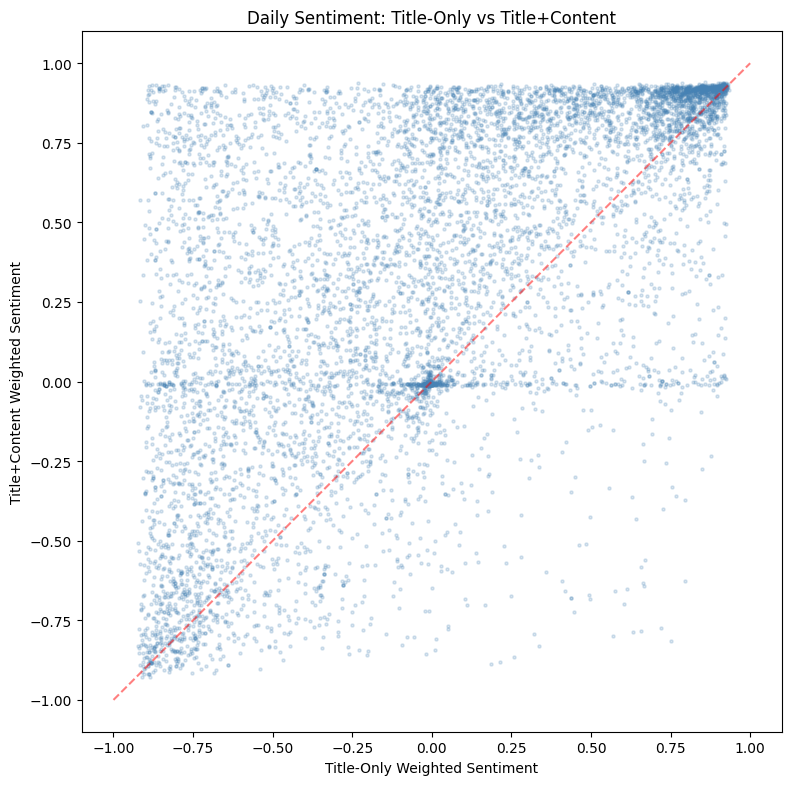

Correlation between title-only and title+content daily sentiment: 0.6149

If correlation is very high (>0.95), the content body adds minimal information.
If moderate (0.7-0.9), the content provides meaningful additional signal.


In [10]:
# ============================================================
# COMPARE TITLE-ONLY VS TITLE+CONTENT CONFIGURATIONS
# ============================================================

# Merge both on ticker + trading_date to compare
df_compare = df_daily_title_full[['ticker', 'trading_date', 'w_sentiment_score']].merge(
    df_daily_title_content_full[['ticker', 'trading_date', 'w_sentiment_score']],
    on=['ticker', 'trading_date'],
    suffixes=('_title', '_title_content')
).dropna()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_compare['w_sentiment_score_title'], 
           df_compare['w_sentiment_score_title_content'],
           alpha=0.2, s=5, color='steelblue')
ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5)
ax.set_title('Daily Sentiment: Title-Only vs Title+Content')
ax.set_xlabel('Title-Only Weighted Sentiment')
ax.set_ylabel('Title+Content Weighted Sentiment')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

corr = df_compare['w_sentiment_score_title'].corr(df_compare['w_sentiment_score_title_content'])
print(f"Correlation between title-only and title+content daily sentiment: {corr:.4f}")
print("\nIf correlation is very high (>0.95), the content body adds minimal information.")
print("If moderate (0.7-0.9), the content provides meaningful additional signal.")

## Step 7: Save Results

In [11]:
# ============================================================
# SAVE TO DATABASE
# ============================================================
connection = sqlite3.connect(DB_PATH)

df_daily_title_full.to_sql('daily_sentiment_title', connection, if_exists='replace', index=False)
df_daily_title_content_full.to_sql('daily_sentiment_title_content', connection, if_exists='replace', index=False)

# Verify
cursor = connection.cursor()
cursor.execute('SELECT COUNT(*) FROM daily_sentiment_title')
print(f"daily_sentiment_title: {cursor.fetchone()[0]} records")
cursor.execute('SELECT COUNT(*) FROM daily_sentiment_title_content')
print(f"daily_sentiment_title_content: {cursor.fetchone()[0]} records")

connection.close()

# ============================================================
# EXPORT PER-TICKER CSV FILES
# ============================================================
print("\nExporting per-ticker CSV files...")
print("=" * 50)

for ticker, name in TICKERS.items():
    # Title-only
    ticker_title = df_daily_title_full[df_daily_title_full['ticker'] == ticker].copy()
    title_path = os.path.join(OUTPUT_DIR, f'{ticker}_{name}_daily_title.csv')
    ticker_title.to_csv(title_path, index=False)
    
    # Title+content
    ticker_tc = df_daily_title_content_full[df_daily_title_content_full['ticker'] == ticker].copy()
    tc_path = os.path.join(OUTPUT_DIR, f'{ticker}_{name}_daily_title_content.csv')
    ticker_tc.to_csv(tc_path, index=False)
    
    days_with_data = (ticker_tc['article_count'] > 0).sum()
    total_days = len(ticker_tc)
    print(f"{ticker} ({name}): {total_days} trading days, {days_with_data} with articles ({days_with_data/total_days*100:.1f}%)")

print(f"\nAll files exported to: {os.path.abspath(OUTPUT_DIR)}")

daily_sentiment_title: 14560 records
daily_sentiment_title_content: 14560 records

Exporting per-ticker CSV files...
1155.KL (Maybank): 1456 trading days, 1046 with articles (71.8%)
1023.KL (CIMB): 1456 trading days, 992 with articles (68.1%)
1295.KL (PublicBank): 1456 trading days, 1177 with articles (80.8%)
5211.KL (Sunway): 1456 trading days, 1041 with articles (71.5%)
5225.KL (IHH): 1456 trading days, 447 with articles (30.7%)
5285.KL (SDGuthrie): 1456 trading days, 201 with articles (13.8%)
5347.KL (Tenaga): 1456 trading days, 966 with articles (66.3%)
5819.KL (HongLeongBank): 1456 trading days, 943 with articles (64.8%)
6947.KL (CelcomDigi): 1456 trading days, 578 with articles (39.7%)
8869.KL (PressMetal): 1456 trading days, 484 with articles (33.2%)

All files exported to: c:\Users\Suhail\Projects\Capstone_2\data\daily_sentiment_exports


In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 60)
print("DAILY SENTIMENT AGGREGATION - SUMMARY")
print("=" * 60)

print(f"\nTrading calendar source: {calendar_source}")
print(f"Trading days covered: {len(trading_dates_list)}")
print(f"Date range: {trading_dates_list[0]} to {trading_dates_list[-1]}")

print(f"\nTitle-only daily records: {len(df_daily_title_full)}")
print(f"Title+content daily records: {len(df_daily_title_content_full)}")

print(f"\nAggregation method: Confidence-weighted average")
print(f"Missing day handling: NaN (for modelling team to decide)")

print(f"\nOutput columns:")
for col in df_daily_title_content_full.columns:
    print(f"  - {col}")

print(f"\n--- Output Description ---")
print(f"ticker:              Stock ticker")
print(f"trading_date:        Bursa Malaysia trading date")
print(f"article_count:       Number of articles for that stock-day (0 if none)")
print(f"w_sentiment_score:   Confidence-weighted sentiment score (prob_pos - prob_neg)")
print(f"w_prob_pos/neu/neg:  Confidence-weighted FinBERT class probabilities")
print(f"w_strength:          Confidence-weighted max class probability")
print(f"avg_sentiment_score: Simple average sentiment score (for comparison)")
print(f"avg_confidence:      Simple average confidence")
print(f"prop_positive:       Proportion of articles classified POSITIVE")
print(f"prop_neutral:        Proportion of articles classified NEUTRAL")
print(f"prop_negative:       Proportion of articles classified NEGATIVE")
print(f"dominant_sentiment:  Most common directional label for the day")
print(f"\nNaN values indicate trading days with no articles for that stock.")
print(f"article_count = 0 for these days.")

DAILY SENTIMENT AGGREGATION - SUMMARY

Trading calendar source: weekday-only fallback (holidays not excluded)
Trading days covered: 1456
Date range: 2020-08-14 to 2026-03-13

Title-only daily records: 14560
Title+content daily records: 14560

Aggregation method: Confidence-weighted average
Missing day handling: NaN (for modelling team to decide)

Output columns:
  - ticker
  - trading_date
  - article_count
  - w_sentiment_score
  - w_prob_pos
  - w_prob_neu
  - w_prob_neg
  - w_strength
  - avg_sentiment_score
  - avg_confidence
  - prop_positive
  - prop_neutral
  - prop_negative
  - dominant_sentiment

--- Output Description ---
ticker:              Stock ticker
trading_date:        Bursa Malaysia trading date
article_count:       Number of articles for that stock-day (0 if none)
w_sentiment_score:   Confidence-weighted sentiment score (prob_pos - prob_neg)
w_prob_pos/neu/neg:  Confidence-weighted FinBERT class probabilities
w_strength:          Confidence-weighted max class probabi